In [2]:
import os
import pandas as pd
import numpy as np

# 1. Route configuration
CSV_FILE = "benchmark_summary.csv"
LATEX_OUTPUT_FILE = "memory_table.tex"

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(f"The file {CSV_FILE} was not found in the current directory.")

# 2. Load and process empirical data
df = pd.read_csv(CSV_FILE)
df['Mem_GB'] = df['Max_RAM_KB'] / (1024 * 1024)
df['Growth_Factor'] = df['Max_RAM_KB'] / df['Max_RAM_KB'].shift(1)
df['Growth_Factor_Str'] = df['Growth_Factor'].apply(lambda x: f"{x:.2f}x" if pd.notnull(x) else "---")

print("--- PROCESSED EMPIRICAL DATA ---")
print(df[['N_BNs', 'Max_RAM_KB', 'Mem_GB', 'Growth_Factor_Str']])
print("-" * 35)

# 3. Automatically generate LaTeX code for the table (4 columns)
latex_table = r"""\begin{table}[htbp]
\centering
\caption{Empirical RAM memory consumption by number of networks ($N$).}
\label{tab:memory_consumption}
\begin{tabular}{cccc}
\hline
\textbf{Networks ($N$)} & \textbf{Max Memory (KB)} & \textbf{Max Memory (GB)} & \textbf{Growth Factor} \\ \hline
"""

for _, row in df.iterrows():
    n = int(row['N_BNs'])
    kb = f"{int(row['Max_RAM_KB']):,}".replace(",", " ")
    gb = f"{row['Mem_GB']:.2f}"
    factor = row['Growth_Factor_Str']
    latex_table += f"{n} & {kb} & {gb} & {factor} \\\\\n"

latex_table += r"""\hline
\end{tabular}
\end{table}"""

# 4. Save the generated LaTeX code directly to a file
with open(LATEX_OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(f"\n--- GENERATED LATEX TABLE CODE ---")
print(latex_table)
print("-------------------------------------------------")
print(f"✅ LaTeX table file successfully created: {LATEX_OUTPUT_FILE}")

--- PROCESSED EMPIRICAL DATA ---
   N_BNs  Max_RAM_KB    Mem_GB Growth_Factor_Str
0      3       75892  0.072376               ---
1      4       76448  0.072906             1.01x
2      5       78244  0.074619             1.02x
3      6       86388  0.082386             1.10x
4      7      159644  0.152248             1.85x
5      8      565476  0.539280             3.54x
6      9     2167896  2.067467             3.83x
7     10     8166620  7.788296             3.77x
-----------------------------------

--- GENERATED LATEX TABLE CODE ---
\begin{table}[htbp]
\centering
\caption{Empirical RAM memory consumption by number of networks ($N$).}
\label{tab:memory_consumption}
\begin{tabular}{cccc}
\hline
\textbf{Networks ($N$)} & \textbf{Max Memory (KB)} & \textbf{Max Memory (GB)} & \textbf{Growth Factor} \\ \hline
3 & 75 892 & 0.07 & --- \\
4 & 76 448 & 0.07 & 1.01x \\
5 & 78 244 & 0.07 & 1.02x \\
6 & 86 388 & 0.08 & 1.10x \\
7 & 159 644 & 0.15 & 1.85x \\
8 & 565 476 & 0.54 & 3.54x \\
9 & 

✅ Extrapolated plot successfully saved to: memory_extrapolation.pdf


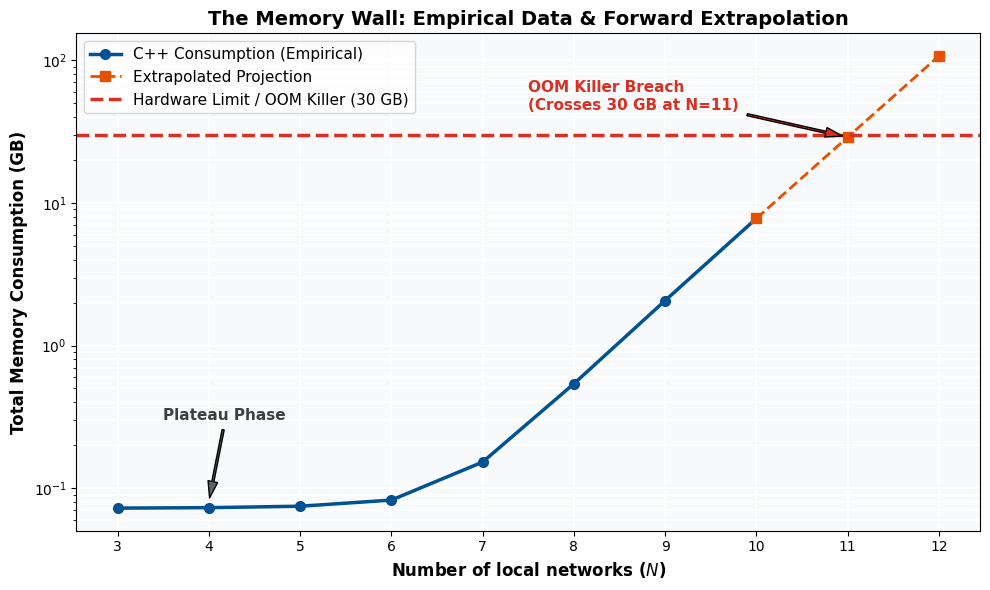

In [4]:
import matplotlib.pyplot as plt

OUTPUT_PDF = "memory_extrapolation.pdf"

# 1. Extract empirical arrays
n_empirical = df['N_BNs'].values
mem_empirical_gb = df['Mem_GB'].values

# 2. Forward Extrapolation for N = 11 and N = 12
# Using the average growth factor of the last transitions (~3.77x)
avg_growth_factor = df['Growth_Factor'].tail(3).mean()

n_extrapolated = np.array([11, 12])
last_mem = mem_empirical_gb[-1]
mem_extrapolated_gb = np.array([
    last_mem * avg_growth_factor,
    last_mem * (avg_growth_factor ** 2)
])

# Combine empirical and extrapolated data for seamless plotting
n_total = np.concatenate([n_empirical, n_extrapolated])
mem_total_gb = np.concatenate([mem_empirical_gb, mem_extrapolated_gb])

# 3. Generate Professional Plot with Extrapolation
plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('#f8f9fa')

# Plot empirical points and line
plt.plot(n_empirical, mem_empirical_gb, marker='o', linestyle='-', color='#005293', linewidth=2.5, markersize=7, label='C++ Consumption (Empirical)')

# Plot extrapolated projection points and dashed line
plt.plot(np.concatenate([[n_empirical[-1]], n_extrapolated]), 
         np.concatenate([[mem_empirical_gb[-1]], mem_extrapolated_gb]), 
         marker='s', linestyle='--', color='#e65100', linewidth=2.0, markersize=7, label='Extrapolated Projection')

# Hardware Limit / OOM Killer threshold line
plt.axhline(y=30, color='#d93025', linestyle='--', linewidth=2.5, label='Hardware Limit / OOM Killer (30 GB)')

plt.yscale('log')
plt.xlabel('Number of local networks ($N$)', fontsize=12, fontweight='bold')
plt.ylabel('Total Memory Consumption (GB)', fontsize=12, fontweight='bold')
plt.title('The Memory Wall: Empirical Data & Forward Extrapolation', fontsize=14, fontweight='bold')

plt.grid(True, which="both", ls="-", color='white', linewidth=1.5)
plt.xticks(n_total)

# Visual Annotations
plt.annotate('Plateau Phase', xy=(4, 0.08), xytext=(3.5, 0.3),
             arrowprops=dict(facecolor='#5f6368', shrink=0.05, width=1.5, headwidth=7),
             fontsize=11, color='#3c4043', fontweight='bold')

plt.annotate('OOM Killer Breach\n(Crosses 30 GB at N=11)', xy=(11, mem_extrapolated_gb[0]), xytext=(7.5, 45),
             arrowprops=dict(facecolor='#d93025', shrink=0.05, width=1.5, headwidth=7),
             fontsize=11, color='#d93025', fontweight='bold')

plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# Save as PDF for LuaLaTeX compilation
plt.savefig(OUTPUT_PDF, format='pdf', bbox_inches='tight')
print(f"✅ Extrapolated plot successfully saved to: {OUTPUT_PDF}")

# Render inline plot in Jupyter Notebook
plt.show()